What were to total missed pickup by route?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import re
from matplotlib.ticker import FixedFormatter

In [2]:
trash = pd.read_csv('../data/trash_hauler_report.csv')
trash

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/01/17,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1.727970e+06,686779.478089
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [3]:
trash['Request '] = trash['Request '].astype('string')
trash['Description'] = trash['Description'].fillna("").str.lower().astype('string')
trash.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20226 entries, 0 to 20225
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Request Number    20226 non-null  int64  
 1   Date Opened       20226 non-null  object 
 2   Request           20226 non-null  string 
 3   Description       20226 non-null  string 
 4   Incident Address  20217 non-null  object 
 5   Zip Code          20151 non-null  float64
 6   Trash Hauler      19325 non-null  object 
 7   Trash Route       19279 non-null  object 
 8   Council District  20177 non-null  float64
 9   State Plan X      20198 non-null  float64
 10  State Plan Y      20198 non-null  float64
dtypes: float64(4), int64(1), object(4), string(2)
memory usage: 1.7+ MB


In [4]:
trashm = trash.loc[
    (trash['Description'].str.contains('miss') == True) |
    (trash['Request '].str.contains('Missed') == True)]
trashm

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
1,25274,11/01/17,Trash - Curbside/Alley Missed Pickup,curb/trash miss tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1.721259e+06,685444.799565
2,25276,11/01/17,Trash - Curbside/Alley Missed Pickup,curb/trash miss tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1.707027e+06,659887.471571
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
4,25312,11/01/17,Trash - Curbside/Alley Missed Pickup,missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1.710186e+06,664205.101066
7,25327,11/01/17,Trash Collection Complaint,"trash out on time, miss again tuesday. alley",1816 Jo Johnston Ave,37203.0,METRO,9208,21.0,1.731459e+06,666013.601229
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/01/19,Trash - Curbside/Alley Missed Pickup,missed...neighbors missed,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1.781137e+06,632448.551144
20222,267126,11/01/19,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1.749711e+06,669201.601569
20223,267130,11/01/19,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1.770293e+06,674936.303809
20224,267134,11/01/19,Trash - Curbside/Alley Missed Pickup,caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1.785225e+06,627146.400187


In [5]:
trashm.loc[:, 'Trash Route'] = trashm['Trash Route'].astype('string')
trasho = trashm.loc[trashm['Trash Route'] == '2206']
trasho

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
369,29524,11/22/17,Trash - Curbside/Alley Missed Pickup,seems the whole street missed {trash} curb. sh...,2705 Combs Dr,37207.0,WASTE IND,2206,2.0,1.735119e+06,686591.116119
452,30822,11/30/17,Trash - Curbside/Alley Missed Pickup,"curb/trash miss for pickup, 2 carts out.",314 Prince Ave B,37207.0,WASTE IND,2206,5.0,1.743874e+06,682610.621859
612,32944,12/12/17,Trash - Curbside/Alley Missed Pickup,missed pick up but picked up neighbors. caller...,519 yokley rd,37207.0,WASTE IND,2206,2.0,1.735186e+06,685173.230807
780,35000,12/26/17,Trash - Curbside/Alley Missed Pickup,trash was not picked up,430 e trinity ln b,37207.0,WASTE IND,2206,5.0,1.744747e+06,682158.063623
...,...,...,...,...,...,...,...,...,...,...,...
15635,223092,07/31/19,Trash - Curbside/Alley Missed Pickup,entire street missed,"1206 Avondale Cir, Nashville, TN 37207, United...",37207.0,WASTE IND,2206,2.0,1.738305e+06,683641.850176
17901,242675,09/05/19,Trash - Curbside/Alley Missed Pickup,missed,"2656 Combs Dr, Nashville, TN 37207, United States",37207.0,WASTE IND,2206,2.0,1.735149e+06,686377.071701
18534,251310,09/25/19,Trash - Curbside/Alley Missed Pickup,"no one pick up tuesday/on their side, curb {why?}","2816 Old Matthews Rd, Nashville, TN 37207, Uni...",37207.0,WASTE IND,2206,2.0,1.734177e+06,686448.799705
18634,252421,09/27/19,Trash - Curbside/Alley Missed Pickup,wants a supervisor to call her tired of having...,"2816 Old Matthews Rd, Nashville, TN 37207, Uni...",37207.0,WASTE IND,2206,2.0,1.734177e+06,686448.799705


In [6]:
trashr = trashm.value_counts('Trash Route').to_frame().reset_index()

In [7]:
trashr

,Trash Route,count
0,4504,329
1,3302,291
2,4404,255
3,9303,245
4,1303,240
...,...,...
167,2405S,3
168,4201S,2
169,2505S,2
170,3303S,2


In [8]:
trasha = pd.merge(trashr, trashm, left_on="Trash Route", right_on="Trash Route", how="left")
trasha

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
0,4504,329,25941,11/03/17,Trash Collection Complaint,missed again. has had multiple issues with the...,1300 Rural Hill Rd,37013.0,RED RIVER,32.0,1.777932e+06,628763.202134
1,4504,329,26141,11/06/17,Trash Collection Complaint,trash missed almost every week - adv client to...,5550 Mt View Rd,37013.0,RED RIVER,32.0,1.780680e+06,622557.601894
2,4504,329,28863,11/17/17,Trash - Curbside/Alley Missed Pickup,they skipped my house for trash pickup,605 Welshcrest Pl,37013.0,RED RIVER,32.0,1.776990e+06,632123.549540
3,4504,329,29146,11/20/17,Trash - Curbside/Alley Missed Pickup,missed. states has been missed twice in two we...,1312 Rice Hill Cir,37013.0,RED RIVER,32.0,1.779104e+06,631484.695500
4,4504,329,30044,11/27/17,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed in area,760 PIPPIN DR,37013.0,RED RIVER,28.0,1.775550e+06,629604.762170
...,...,...,...,...,...,...,...,...,...,...,...,...
16967,2505S,2,55929,03/23/18,Trash - Curbside/Alley Missed Pickup,cart still out,2721 smith springs rd,37217.0,RED RIVER,29.0,1.783988e+06,639863.867987
16968,2505S,2,233039,08/16/19,Trash - Curbside/Alley Missed Pickup,"curb trash/missed friday, why did they take ot...","1141 Nashboro Blvd, Nashville, TN 37217, Unite...",37217.0,RED RIVER,29.0,1.779825e+06,639719.043450
16969,3303S,2,27234,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed pick up please note if resident ...,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728043e+06,640999.191433
16970,3303S,2,64993,05/03/18,Trash - Curbside/Alley Missed Pickup,missed trash pickup,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728042e+06,641001.685859


In [9]:
trashu = trashm[['Trash Hauler', 'Trash Route']]
trashu = trashu.sort_values(by='Trash Route', ascending=False)
trashu['Trash Hauler'].isnull().sum()
trashu['Trash Route'].isnull().sum()
trashb = trashu[trashu['Trash Route'].isna() == False]
trashb

,Trash Hauler,Trash Route
7915,METRO,9508
1908,METRO,9508
1943,METRO,9508
1931,METRO,9508
6919,METRO,9508
...,...,...
1156,RED RIVER,1201
6652,RED RIVER,1201
19321,RED RIVER,1201
19322,RED RIVER,1201


In [10]:
trashb.value_counts('Trash Hauler').sum()

16939

In [11]:
trashb.value_counts('Trash Route').sum()

16972

In [12]:
trashb['Trash Hauler'].isna().sum()

33

In [13]:
trashb

,Trash Hauler,Trash Route
7915,METRO,9508
1908,METRO,9508
1943,METRO,9508
1931,METRO,9508
6919,METRO,9508
...,...,...
1156,RED RIVER,1201
6652,RED RIVER,1201
19321,RED RIVER,1201
19322,RED RIVER,1201


In [14]:
trashb['Trash Hauler'] = trashb['Trash Hauler'].astype('string')
trashb['Trash Hauler'] = trashb['Trash Hauler'].str.upper()
trashb

C:\Users\isiyb\AppData\Local\Temp\ipykernel_6064\868050991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trashb['Trash Hauler'] = trashb['Trash Hauler'].astype('string')
C:\Users\isiyb\AppData\Local\Temp\ipykernel_6064\868050991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trashb['Trash Hauler'] = trashb['Trash Hauler'].str.upper()


,Trash Hauler,Trash Route
7915,METRO,9508
1908,METRO,9508
1943,METRO,9508
1931,METRO,9508
6919,METRO,9508
...,...,...
1156,RED RIVER,1201
6652,RED RIVER,1201
19321,RED RIVER,1201
19322,RED RIVER,1201


In [15]:
trashb.value_counts('Trash Route')

Trash Route
4504     329
3302     291
4404     255
9303     245
1303     240
        ... 
2405S      3
4201S      2
2505S      2
3303S      2
1502S      1
Name: count, Length: 172, dtype: int64

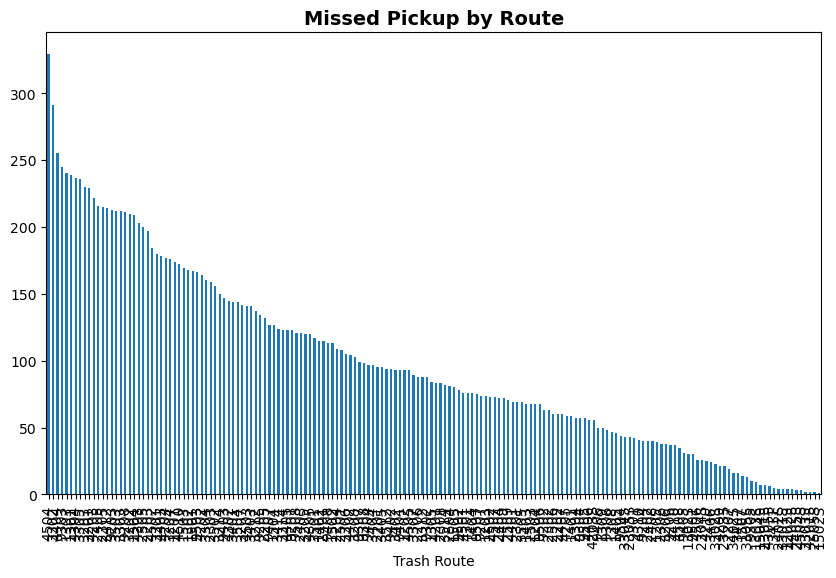

In [16]:
trashb['Trash Route'].value_counts().plot(kind = 'bar', figsize = (10,6))               
# plt.xticks(rotation = 0, fontsize = 12)
plt.title('Missed Pickup by Route', fontsize = 14, fontweight = 'bold');

In [17]:
trashg = trashb.value_counts('Trash Route').to_frame().reset_index()

In [18]:
trashg

,Trash Route,count
0,4504,329
1,3302,291
2,4404,255
3,9303,245
4,1303,240
...,...,...
167,2405S,3
168,4201S,2
169,2505S,2
170,3303S,2


In [19]:
trashg.value_counts('Trash Route')

Trash Route
1201     1
4305S    1
4205     1
4209     1
4210     1
        ..
2505     1
2505S    1
2506     1
2509     1
9508     1
Name: count, Length: 172, dtype: int64

In [20]:
trashg['Trash Route'].isna().sum()

0

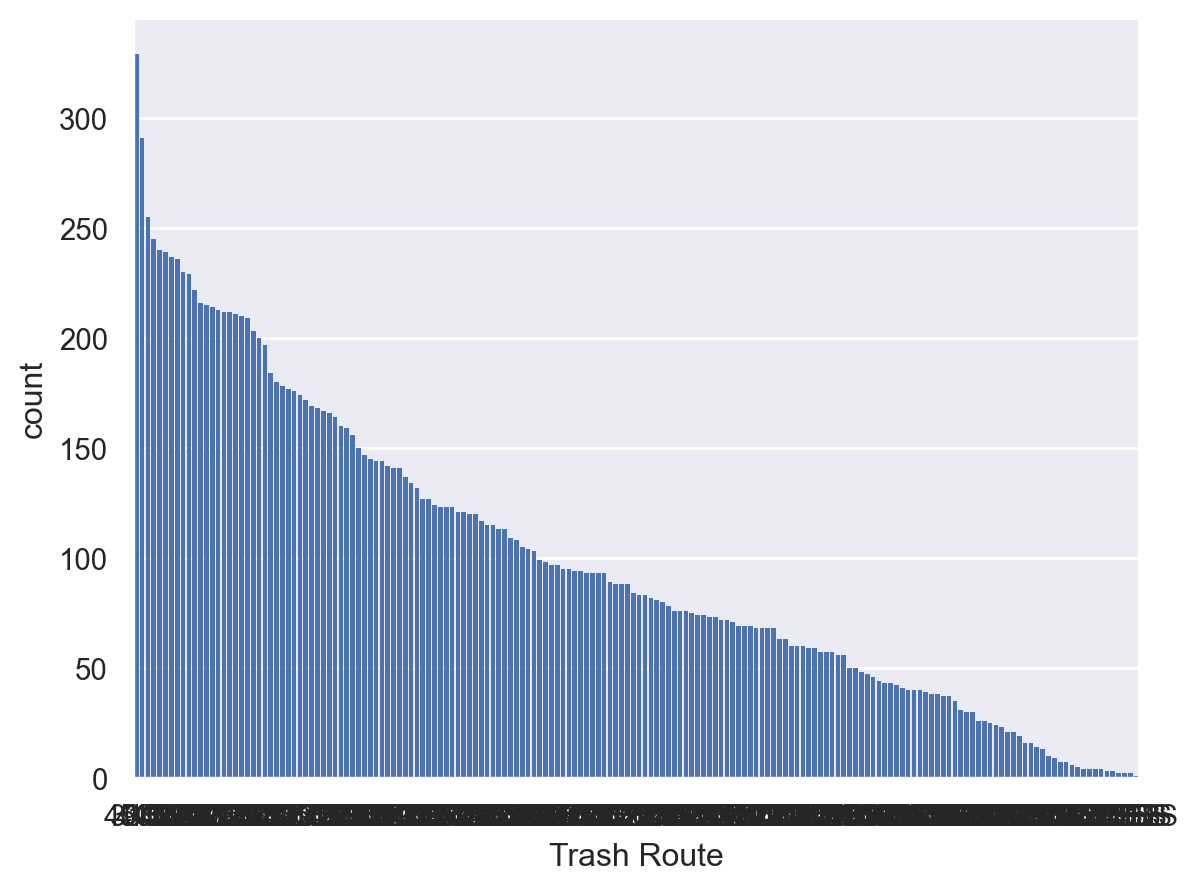

In [21]:
so.Plot(trashg, x="Trash Route", y="count").add(so.Bar())

In [59]:
trashq = pd.merge(trashg, trashm, left_on=['Trash Route'], right_on=['Trash Route'], how="left")
trashq

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
0,4504,329,25941,11/03/17,Trash Collection Complaint,missed again. has had multiple issues with the...,1300 Rural Hill Rd,37013.0,RED RIVER,32.0,1.777932e+06,628763.202134
1,4504,329,26141,11/06/17,Trash Collection Complaint,trash missed almost every week - adv client to...,5550 Mt View Rd,37013.0,RED RIVER,32.0,1.780680e+06,622557.601894
2,4504,329,28863,11/17/17,Trash - Curbside/Alley Missed Pickup,they skipped my house for trash pickup,605 Welshcrest Pl,37013.0,RED RIVER,32.0,1.776990e+06,632123.549540
3,4504,329,29146,11/20/17,Trash - Curbside/Alley Missed Pickup,missed. states has been missed twice in two we...,1312 Rice Hill Cir,37013.0,RED RIVER,32.0,1.779104e+06,631484.695500
4,4504,329,30044,11/27/17,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed in area,760 PIPPIN DR,37013.0,RED RIVER,28.0,1.775550e+06,629604.762170
...,...,...,...,...,...,...,...,...,...,...,...,...
16967,2505S,2,55929,03/23/18,Trash - Curbside/Alley Missed Pickup,cart still out,2721 smith springs rd,37217.0,RED RIVER,29.0,1.783988e+06,639863.867987
16968,2505S,2,233039,08/16/19,Trash - Curbside/Alley Missed Pickup,"curb trash/missed friday, why did they take ot...","1141 Nashboro Blvd, Nashville, TN 37217, Unite...",37217.0,RED RIVER,29.0,1.779825e+06,639719.043450
16969,3303S,2,27234,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed pick up please note if resident ...,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728043e+06,640999.191433
16970,3303S,2,64993,05/03/18,Trash - Curbside/Alley Missed Pickup,missed trash pickup,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728042e+06,641001.685859


In [60]:
trashq['Trash Route'].isna().sum()

0

In [63]:
trashq.value_counts('Trash Route')

Trash Route
4504     329
3302     291
4404     255
9303     245
1303     240
        ... 
2405S      3
4201S      2
2505S      2
3303S      2
1502S      1
Name: count, Length: 172, dtype: int64

In [62]:
trashq=trashq[trashq['Trash Route'].isna() == False]
trashq['Trash Route'].isna().sum()

0

In [25]:
trashq['Trash Hauler'] = trashq['Trash Hauler'].str.upper()

In [26]:
# empty_formatter = FixedFormatter([])
# (
#     so.Plot(trashq, "Trash Route", "count")
#     .add(so.Bar())
#     .layout(size=(25, 7))
#     .label(x=None, y=None)
#     .scale(
#            x=so.Continuous().tick().label(formatter = empty_formatter),
#            y=so.Continuous().tick().label(formatter = empty_formatter)
#            )
#     .show()
# )

<Axes: xlabel='Trash Route', ylabel='count'>

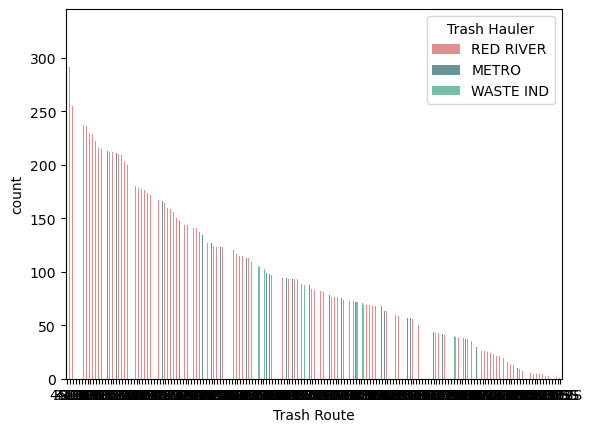

In [27]:
sns.barplot(data=trashq, x="Trash Route", y="count", hue="Trash Hauler", palette=['lightcoral', 'cadetblue', 'mediumaquamarine'])

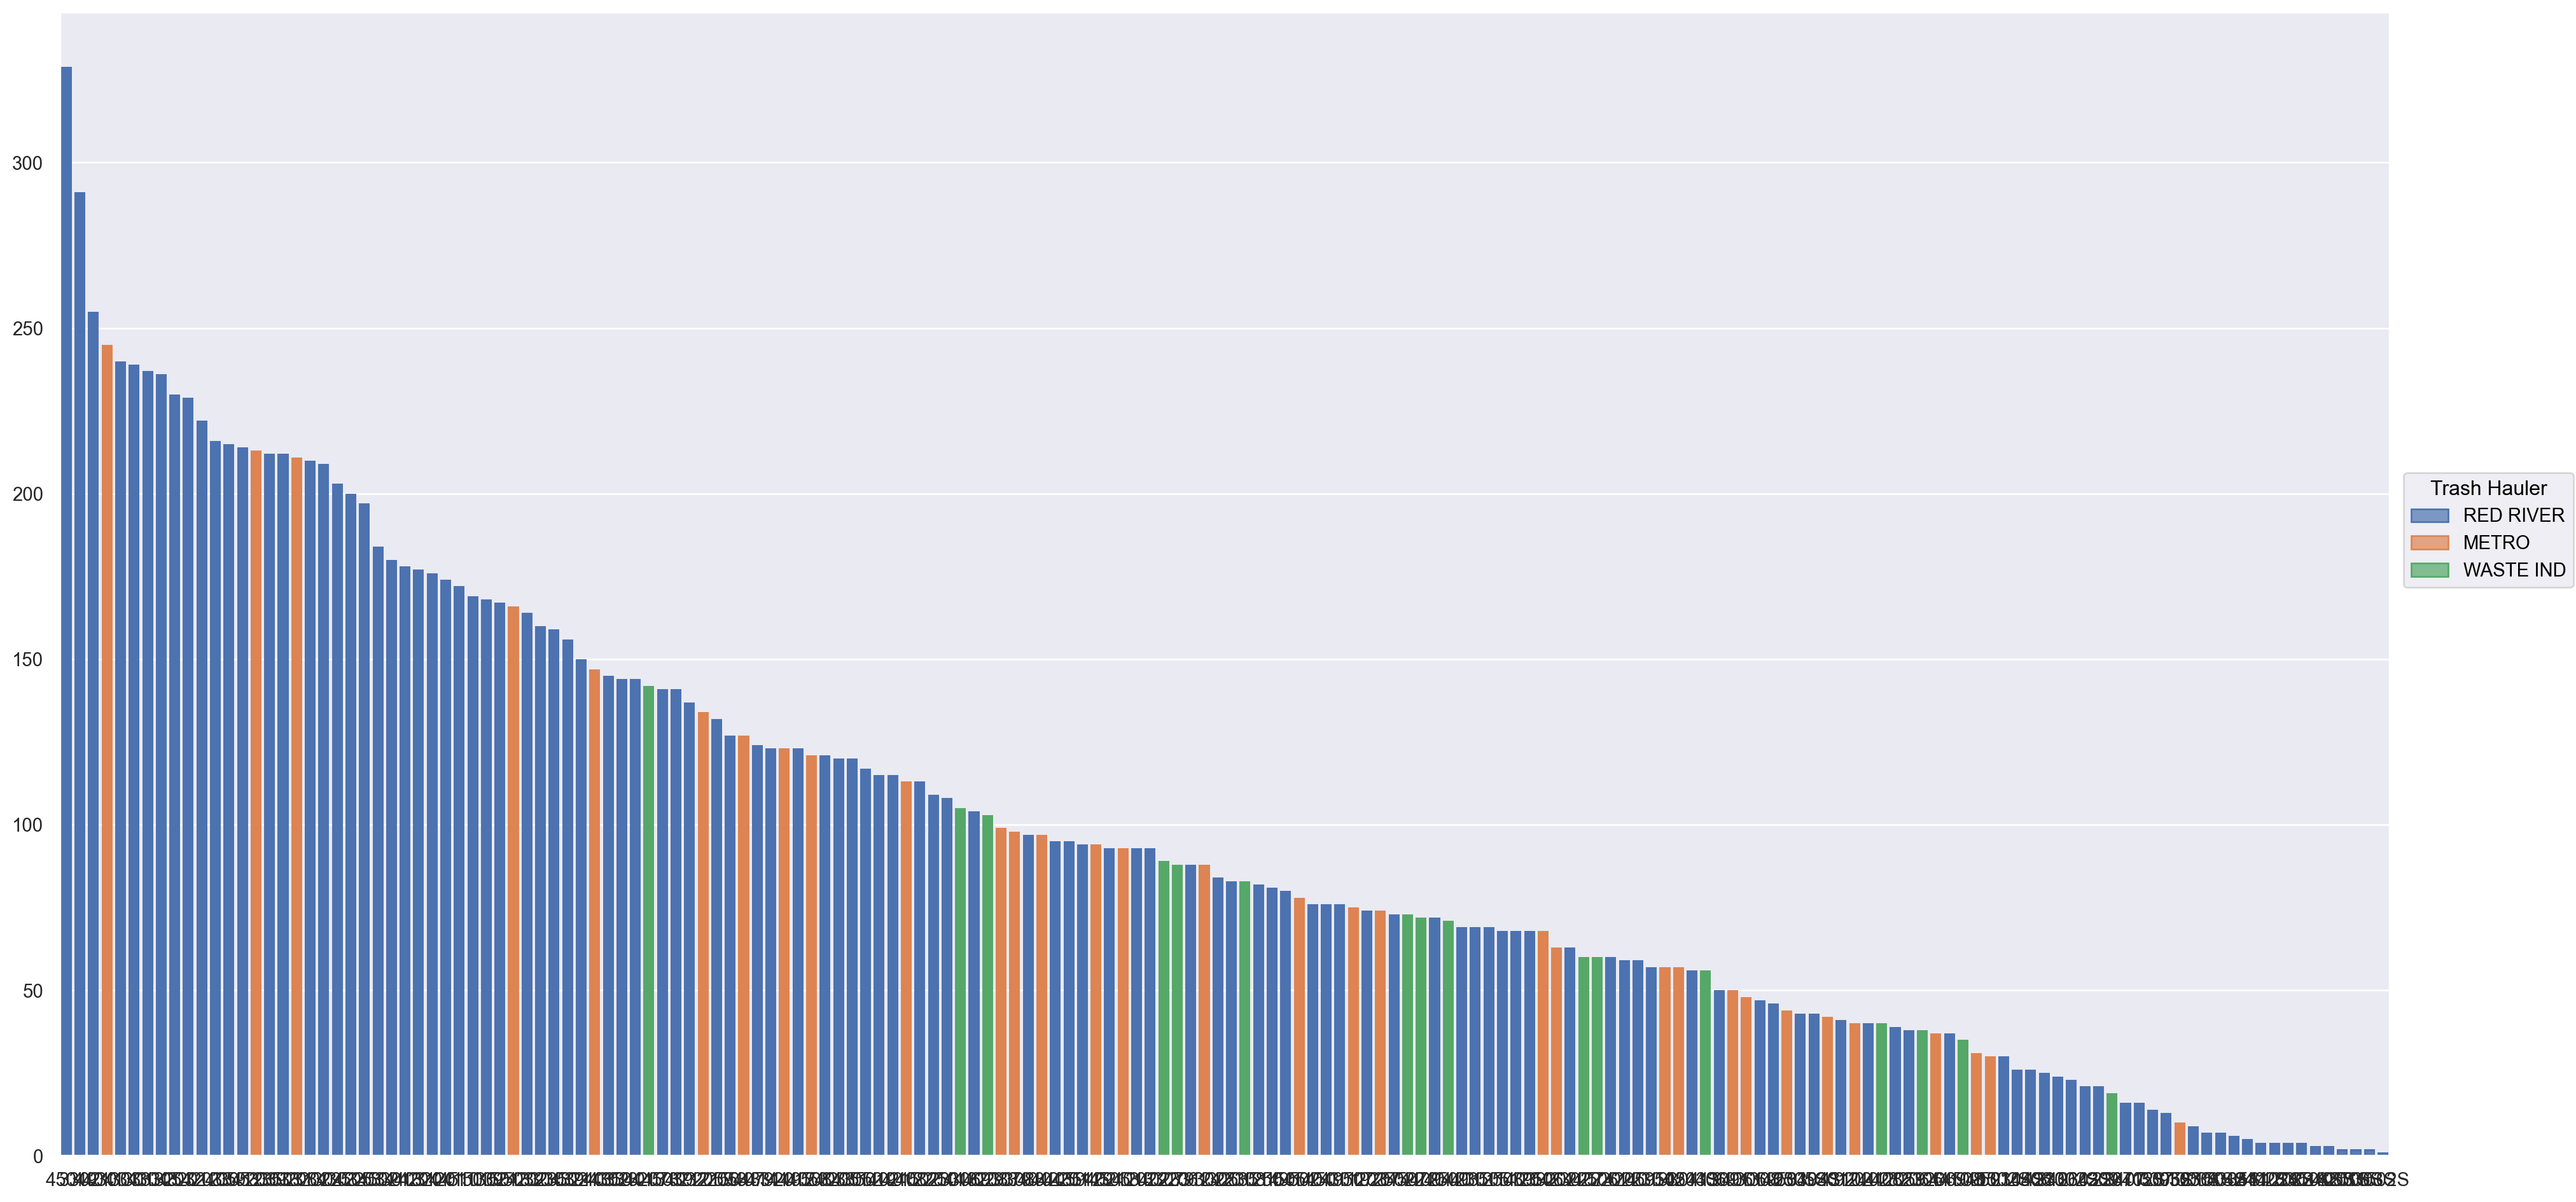

In [28]:
so.Plot(trashq, x="Trash Route", y="count", color="Trash Hauler").layout(size=(20, 10)).add(so.Bar()).label(x=None, y=None)

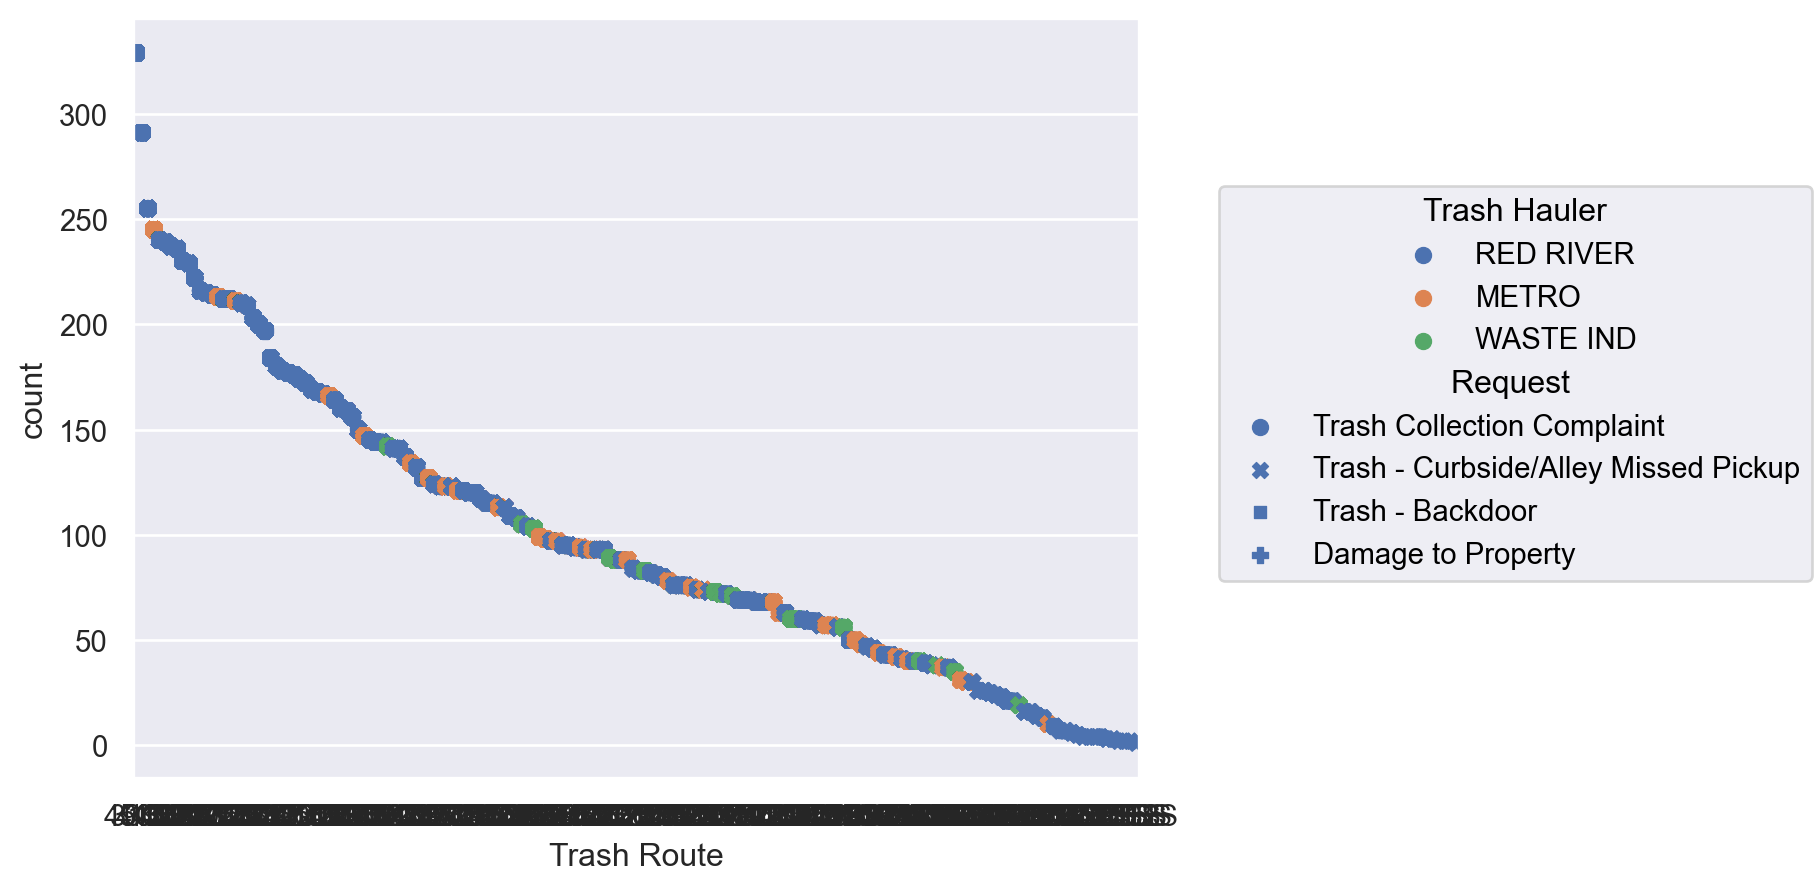

In [29]:
p1 = so.Plot(trashq, "Trash Route", "count", color = "Trash Hauler", marker = "Request ")
p1.add(so.Dot())

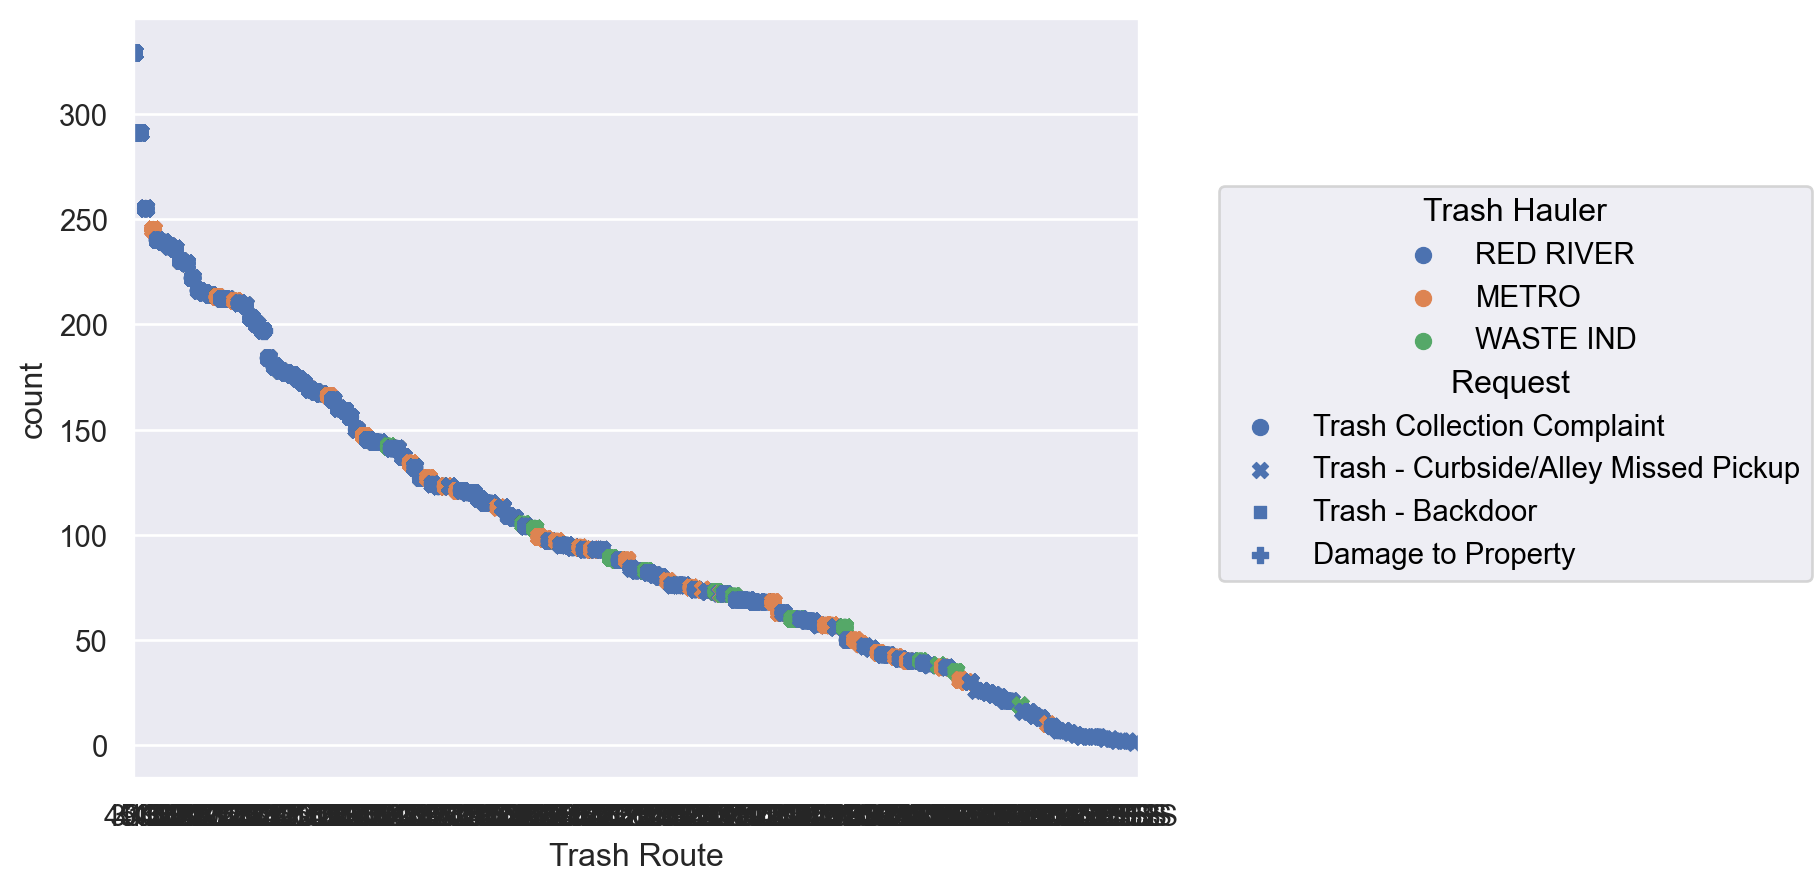

In [30]:
(
    so.Plot(trashq, "Trash Route", "count", color = "Trash Hauler", marker = "Request ")
    .add(so.Dot(), so.Dodge(), so.Jitter(1))
)

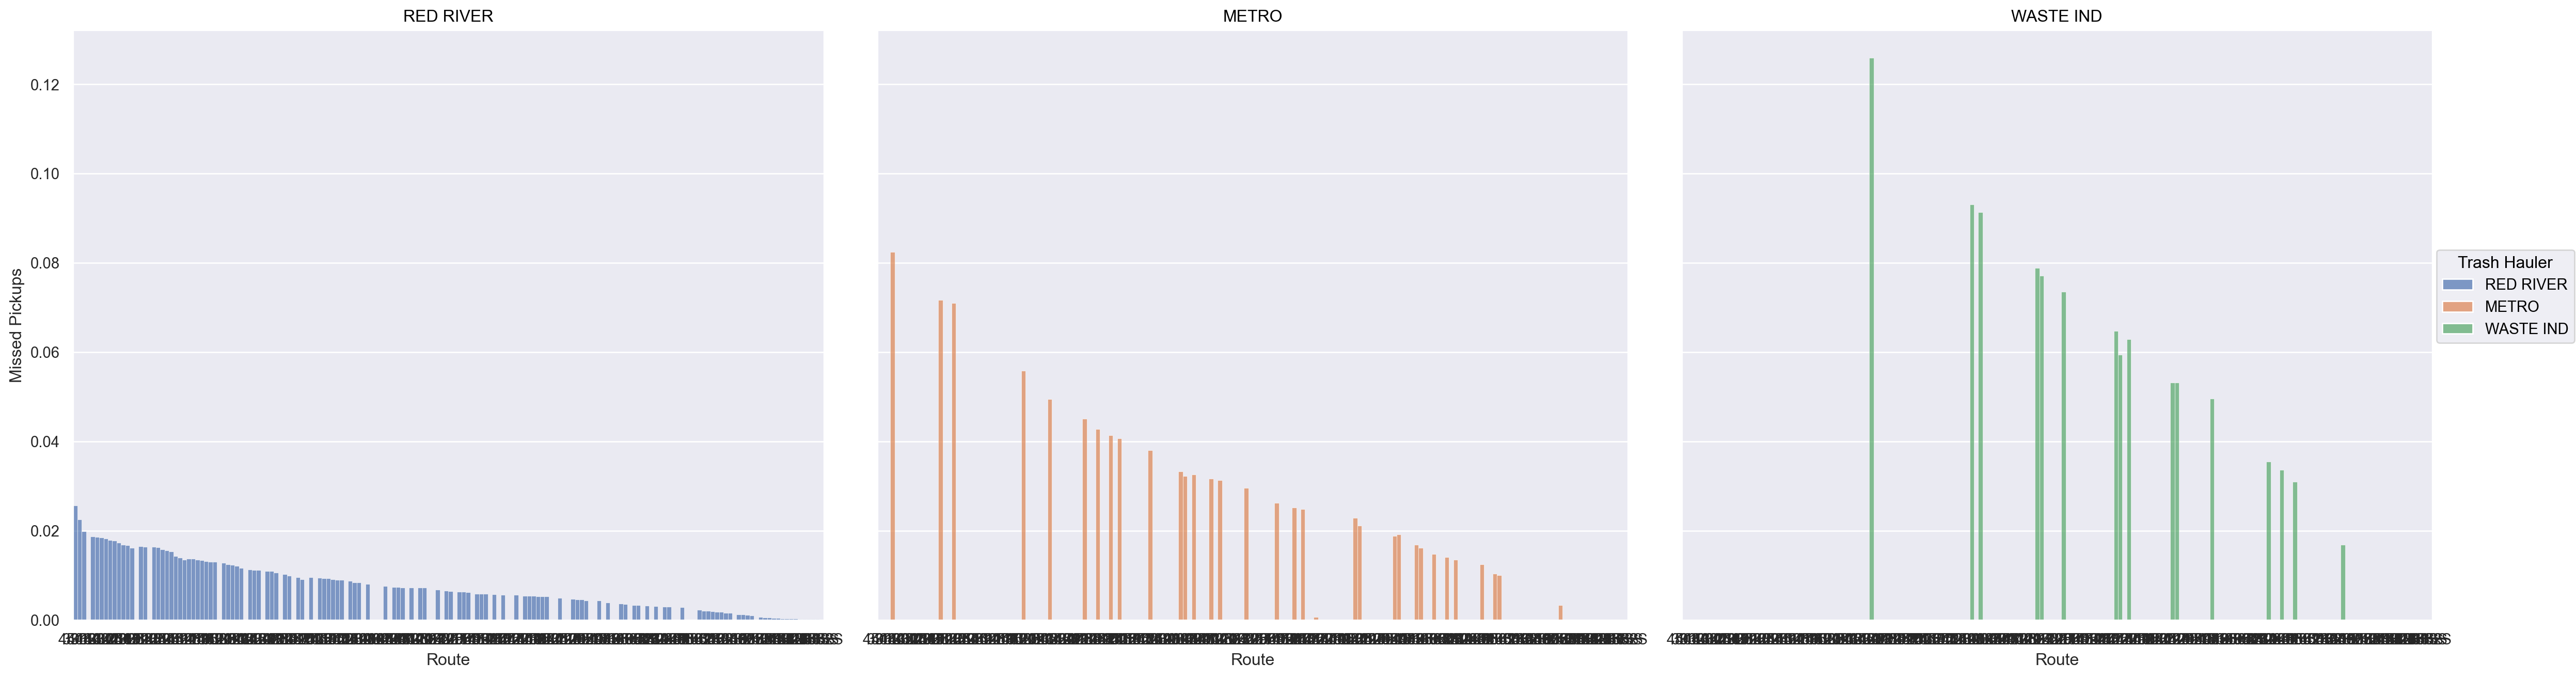

In [31]:
p = (so.Plot(trashq, "Trash Route", color="Trash Hauler")
     .layout(size=(25, 7))
     .label(y="Missed Pickups", x="Route"))
p = p.facet("Trash Hauler")
p.add(so.Bars(), so.Hist(stat="proportion", common_norm=False, bins=50))

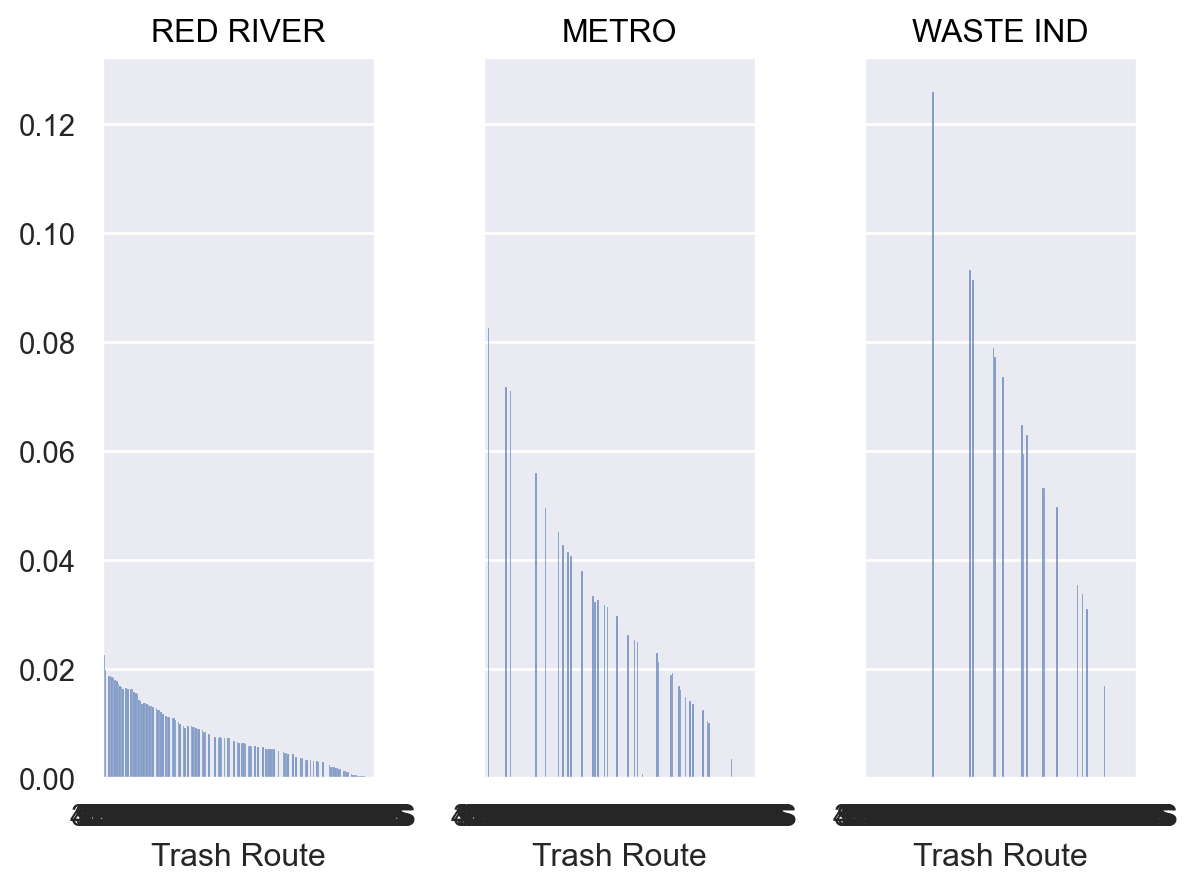

In [32]:
p = so.Plot(trashq, "Trash Route")
p = p.facet("Trash Hauler")
p.add(so.Bars(), so.Hist(stat="proportion", common_norm=False))

so.Plot(trashq, x="Trash Route", y="count", color="Trash Hauler").layout(size=(20, 10)).add(so.Bar()).label(x=None, y=None)

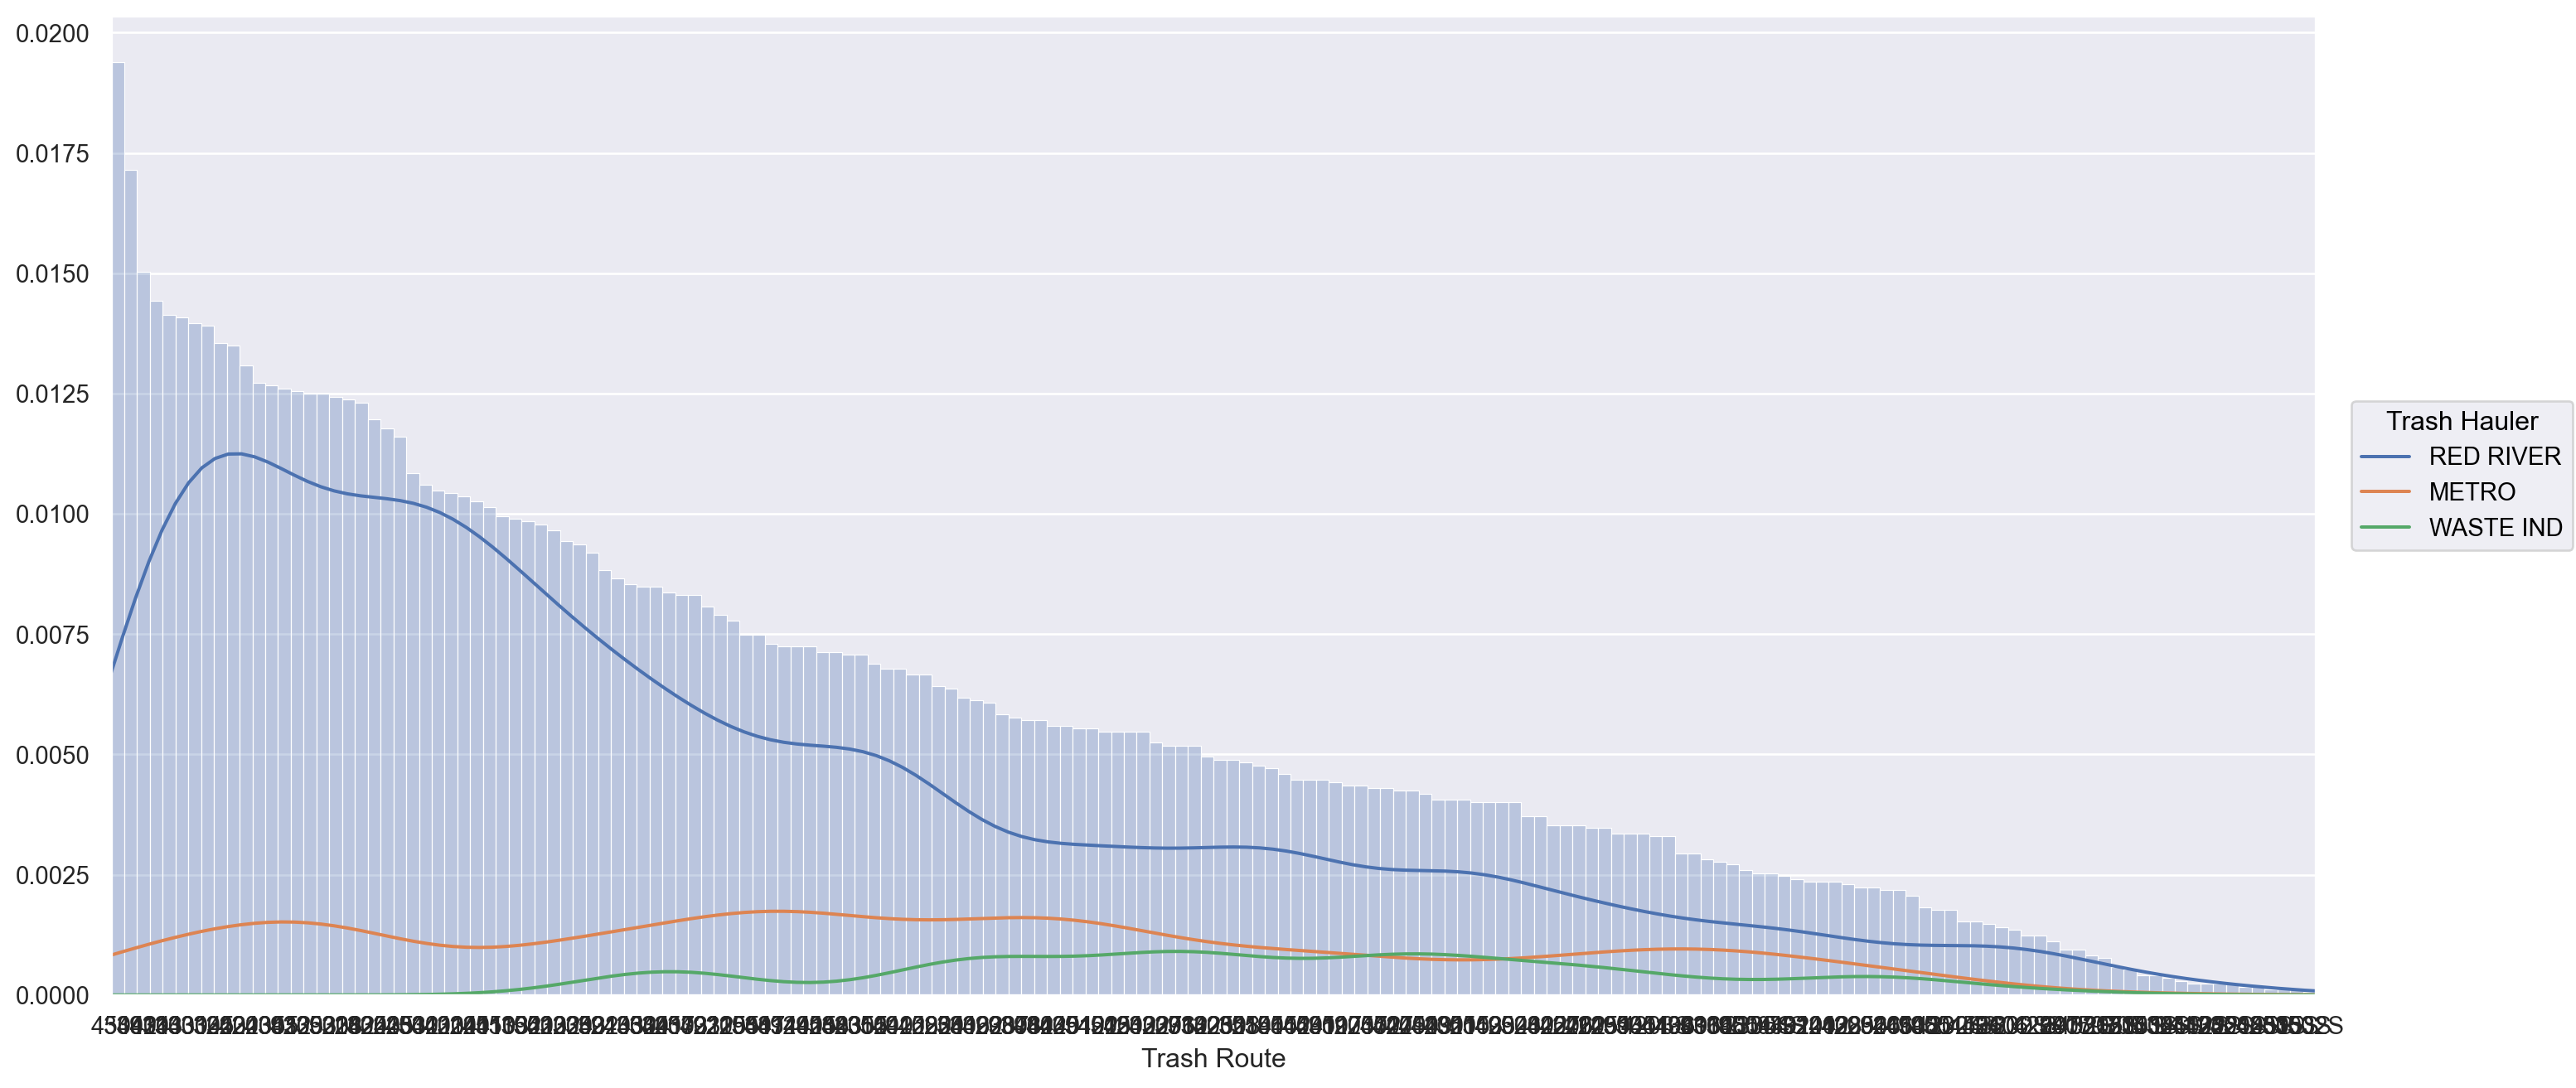

In [33]:
p = so.Plot(trashq, x="Trash Route").layout(size=(15,7))
p.add(so.Area(), so.KDE())
p2 = p.add(so.Bars(alpha=.3), so.Hist("density"))
p2.add(so.Line(), so.KDE(), color="Trash Hauler")

In [35]:
trashq['Trash Route'] = pd.to_numeric(trashq['Trash Route'], downcast='integer', errors='coerce')
# trashq['Trash Route'] = trashq.int('Trash Route')
trashq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16972 entries, 0 to 16971
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trash Route       16643 non-null  float64
 1   count             16972 non-null  int64  
 2   Request Number    16972 non-null  int64  
 3   Date Opened       16972 non-null  object 
 4   Request           16972 non-null  string 
 5   Description       16972 non-null  string 
 6   Incident Address  16970 non-null  object 
 7   Zip Code          16935 non-null  float64
 8   Trash Hauler      16939 non-null  object 
 9   Council District  16954 non-null  float64
 10  State Plan X      16965 non-null  float64
 11  State Plan Y      16965 non-null  float64
dtypes: float64(5), int64(2), object(3), string(2)
memory usage: 1.6+ MB


<Axes: xlabel='count', ylabel='Density'>

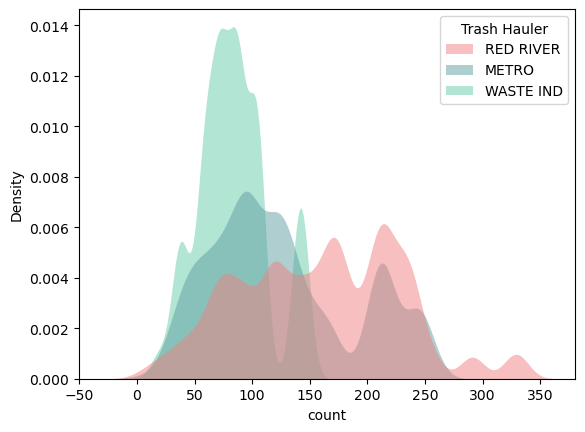

In [36]:
sns.kdeplot(
   data=trashq, x="count", hue="Trash Hauler",
   fill=True, common_norm=False, palette=['lightcoral', 'cadetblue', 'mediumaquamarine'],
   alpha=.5, linewidth=0,
)

In [37]:
trasht = trashq.groupby(['Trash Route']).count()
trasht

,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
Trash Route,,,,,,,,,,,
1201.0,174,174,174,174,174,174,174,174,174,174,174
1202.0,93,93,93,93,93,93,93,93,93,93,93
1203.0,74,74,74,74,74,74,74,74,74,74,74
1204.0,68,68,68,68,68,68,68,68,68,68,68
1205.0,39,39,39,39,39,39,39,39,39,39,39
...,...,...,...,...,...,...,...,...,...,...,...
9504.0,44,44,44,44,44,44,44,44,44,44,44
9505.0,57,57,57,57,57,57,57,56,57,57,57
9506.0,68,68,68,68,68,68,68,68,68,68,68


<Axes: xlabel='Trash Route', ylabel='Density'>

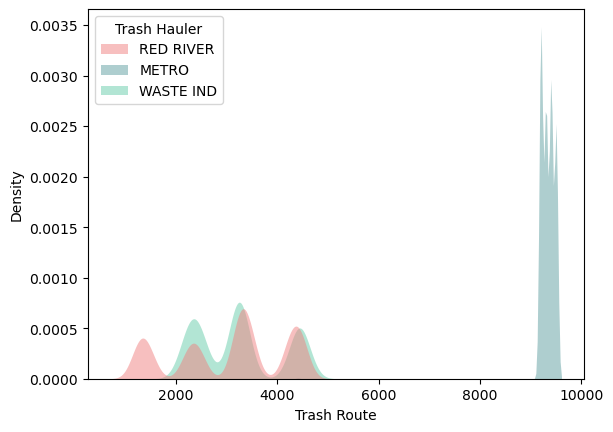

In [38]:
sns.kdeplot(
   data=trashq, x="Trash Route", hue="Trash Hauler",
   fill=True, common_norm=False, palette=['lightcoral', 'cadetblue', 'mediumaquamarine'],
   alpha=.5, linewidth=0,
)

In [39]:
trasht

,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
Trash Route,,,,,,,,,,,
1201.0,174,174,174,174,174,174,174,174,174,174,174
1202.0,93,93,93,93,93,93,93,93,93,93,93
1203.0,74,74,74,74,74,74,74,74,74,74,74
1204.0,68,68,68,68,68,68,68,68,68,68,68
1205.0,39,39,39,39,39,39,39,39,39,39,39
...,...,...,...,...,...,...,...,...,...,...,...
9504.0,44,44,44,44,44,44,44,44,44,44,44
9505.0,57,57,57,57,57,57,57,56,57,57,57
9506.0,68,68,68,68,68,68,68,68,68,68,68


In [64]:
trashq.value_counts('Trash Route')

Trash Route
4504     329
3302     291
4404     255
9303     245
1303     240
        ... 
2405S      3
4201S      2
2505S      2
3303S      2
1502S      1
Name: count, Length: 172, dtype: int64

In [41]:
trashy = trashm.loc[trashm['Trash Hauler']=='WASTE IND']
trashy

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
3,25307,11/01/17,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1.735692e+06,685027.245923
94,25972,11/03/17,Trash - Curbside/Alley Missed Pickup,missed.,916 Petway Ave,37206.0,WASTE IND,2509,5.0,1.746483e+06,675576.311639
192,27229,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed past 2 weeks,415 35th ave N,37209.0,WASTE IND,3306,21.0,1.724396e+06,663795.769164
194,27242,11/09/17,Trash - Curbside/Alley Missed Pickup,cust says missed pickup,918 W GREENWOOD AVE,37206.0,WASTE IND,2509,5.0,1.746589e+06,676985.599246
210,27511,11/13/17,Trash - Curbside/Alley Missed Pickup,missed pick up - unit c,27 hart st C,37210.0,WASTE IND,4409,17.0,1.744013e+06,659286.402245
...,...,...,...,...,...,...,...,...,...,...,...
20096,265871,10/30/19,Trash Collection Complaint,today makes 3 weeks missed trash/curb {sit's o...,"4001 Nebraska Ave, Nashville, TN 37209, United...",37209.0,WASTE IND,2308,24.0,1.722556e+06,659684.000570
20115,266137,10/30/19,Trash Collection Complaint,"2 weeks missed wednesday, sit's on nevada ave ...","301 33rd Ave N, Nashville, TN 37209, United St...",37209.0,WASTE IND,2308,24.0,1.725182e+06,662212.800027
20137,266298,10/31/19,Trash - Curbside/Alley Missed Pickup,missed trash pick up.,"403 Merritt Ave, Nashville, TN 37203, USA",37203.0,WASTE IND,2408,17.0,1.742765e+06,658152.089866
20180,266711,11/01/19,Trash - Curbside/Alley Missed Pickup,missed trash pick up here/ got neighbors just ...,"907 N 14th St, Nashville, TN 37206, United States",37206.0,WASTE IND,2509,6.0,1.748838e+06,675118.401004


In [42]:
trashy.sort_values(by='Trash Route', ascending=False)

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
11932,169289,04/15/19,Trash - Curbside/Alley Missed Pickup,still out,"1108 Glenview Dr, Nashville, TN 37206, United ...",37206.0,WASTE IND,4508,6.0,1.746826e+06,667241.163157
12667,184048,05/14/19,Trash - Curbside/Alley Missed Pickup,missed trash,"512 S 11th St, Nashville, TN 37206, United States",37206.0,WASTE IND,4508,6.0,1.746779e+06,669497.602018
2166,51630,03/06/18,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed also,802 s 12th st,37206.0,WASTE IND,4508,6.0,1.747086e+06,667903.864418
13058,190590,05/28/19,Trash - Curbside/Alley Missed Pickup,miss,"1003 Lenore St, Nashville, Tennessee, 37206",37206.0,WASTE IND,4508,6.0,1.746350e+06,667795.353576
2258,52657,03/09/18,Trash - Curbside/Alley Missed Pickup,missed pick up,718 s 12th st,37206.0,WASTE IND,4508,6.0,1.747082e+06,668060.429755
...,...,...,...,...,...,...,...,...,...,...,...
4201,76696,06/20/18,Trash - Curbside/Alley Missed Pickup,missed pick up on toney rd for 3 weeks.,405 Toney RD,37207.0,WASTE IND,2206,2.0,1.734439e+06,684091.303089
4200,76684,06/20/18,Trash - Curbside/Alley Missed Pickup,missed for two weeks.,425 TONEY RD,37207.0,WASTE IND,2206,2.0,1.734666e+06,684582.531956
4094,75102,06/14/18,Trash - Backdoor,"waiver good through 5/30/2020, backdoor/trash ...",2705 combs dr,37207.0,WASTE IND,2206,2.0,1.735117e+06,686592.791518
4071,74810,06/13/18,Trash - Curbside/Alley Missed Pickup,curbside trash/miss pick up tuesday.,2229 Whites Creek Pike,37207.0,WASTE IND,2206,2.0,1.734247e+06,684044.194067


<Axes: xlabel='Trash Route', ylabel='Density'>

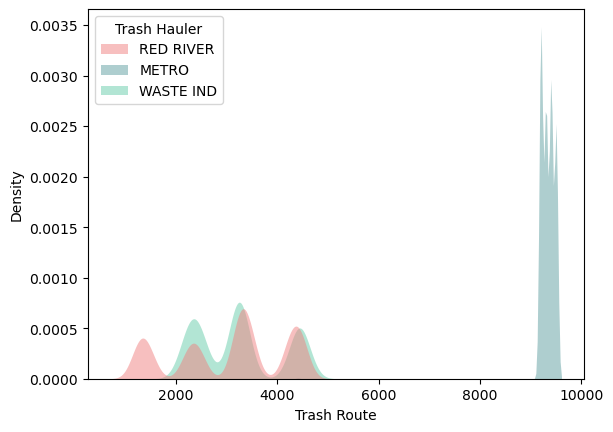

In [43]:
sns.kdeplot(
   data=trashq, x="Trash Route", hue="Trash Hauler",
   fill=True, common_norm=False, palette=['lightcoral', 'cadetblue', 'mediumaquamarine'],
   alpha=.5, linewidth=0,
)

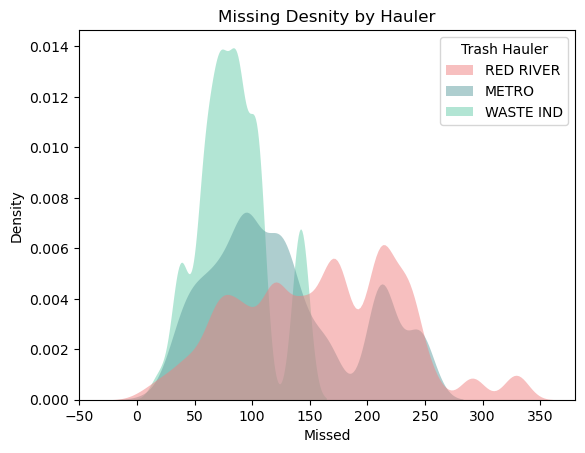

In [44]:
sns.kdeplot(
   data=trashq, x="count", hue="Trash Hauler",
   fill=True, common_norm=False, palette=['lightcoral', 'cadetblue', 'mediumaquamarine'],
   alpha=.5, linewidth=0,
).set(xlabel ="Missed", ylabel = "Density", title ='Missing Desnity by Hauler')
plt.savefig("kde.png")

p = sns.histplot(trashq, x="Trash Route").layout(size=(15,7))
p.add(so.Area(), so.KDE())
p2 = p.add(so.Bars(alpha=.3), so.Hist("density"))
p2.add(so.Line(), so.KDE(), color="Trash Hauler")

In [45]:
trashq 

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
0,4504.0,329,25941,11/03/17,Trash Collection Complaint,missed again. has had multiple issues with the...,1300 Rural Hill Rd,37013.0,RED RIVER,32.0,1.777932e+06,628763.202134
1,4504.0,329,26141,11/06/17,Trash Collection Complaint,trash missed almost every week - adv client to...,5550 Mt View Rd,37013.0,RED RIVER,32.0,1.780680e+06,622557.601894
2,4504.0,329,28863,11/17/17,Trash - Curbside/Alley Missed Pickup,they skipped my house for trash pickup,605 Welshcrest Pl,37013.0,RED RIVER,32.0,1.776990e+06,632123.549540
3,4504.0,329,29146,11/20/17,Trash - Curbside/Alley Missed Pickup,missed. states has been missed twice in two we...,1312 Rice Hill Cir,37013.0,RED RIVER,32.0,1.779104e+06,631484.695500
4,4504.0,329,30044,11/27/17,Trash - Curbside/Alley Missed Pickup,missed pick up - others missed in area,760 PIPPIN DR,37013.0,RED RIVER,28.0,1.775550e+06,629604.762170
...,...,...,...,...,...,...,...,...,...,...,...,...
16967,NaN,2,55929,03/23/18,Trash - Curbside/Alley Missed Pickup,cart still out,2721 smith springs rd,37217.0,RED RIVER,29.0,1.783988e+06,639863.867987
16968,NaN,2,233039,08/16/19,Trash - Curbside/Alley Missed Pickup,"curb trash/missed friday, why did they take ot...","1141 Nashboro Blvd, Nashville, TN 37217, Unite...",37217.0,RED RIVER,29.0,1.779825e+06,639719.043450
16969,NaN,2,27234,11/09/17,Trash - Curbside/Alley Missed Pickup,trash missed pick up please note if resident ...,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728043e+06,640999.191433
16970,NaN,2,64993,05/03/18,Trash - Curbside/Alley Missed Pickup,missed trash pickup,68 ravenwood hills cir,37215.0,RED RIVER,25.0,1.728042e+06,641001.685859


<Axes: xlabel='Trash Route', ylabel='count'>

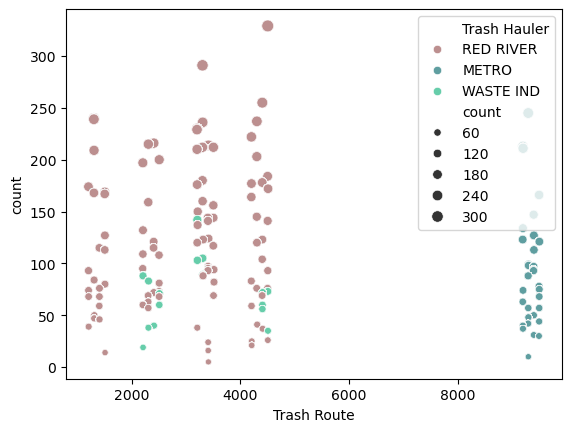

In [46]:
sns.scatterplot(trashq, x="Trash Route", y="count", hue="Trash Hauler", palette=['rosybrown', 'cadetblue', 'mediumaquamarine'], size="count")
# plt.savefig("scatter1.png")

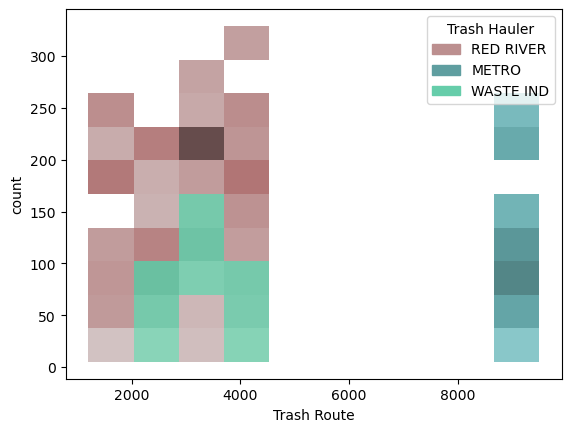

In [47]:
sns.histplot(trashq, x="Trash Route", y="count", bins=10, hue="Trash Hauler", palette=['rosybrown', 'cadetblue', 'mediumaquamarine'])
plt.savefig("heatmap.png")

In [68]:
trashg['count'].mean()

98.67441860465117

In [49]:
trashg['count'].median()

83.5

In [50]:
trashg['count'].max()

329

In [51]:
trashg['count'].min()

1

In [67]:
trashg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Trash Route  172 non-null    object
 1   count        172 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [66]:
trashg['count'].sum()

16972

<Axes: xlabel='Trash Route', ylabel='percent'>

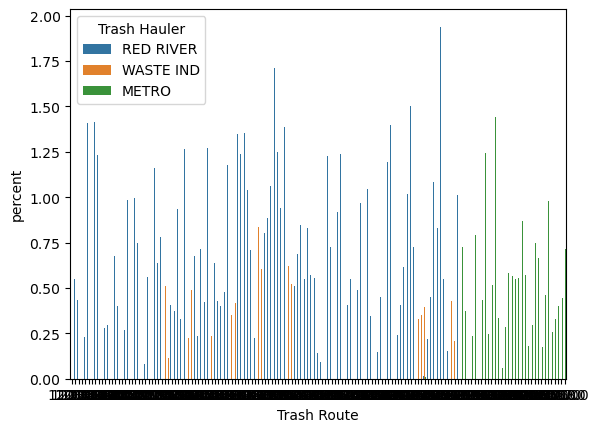

In [53]:
sns.countplot(trashq, x="Trash Route", hue="Trash Hauler", stat="percent")

In [65]:
trashq.value_counts('Trash Route')

Trash Route
4504     329
3302     291
4404     255
9303     245
1303     240
        ... 
2405S      3
4201S      2
2505S      2
3303S      2
1502S      1
Name: count, Length: 172, dtype: int64

In [69]:
trashq['Date Opened'].max()

'12/31/18'

In [70]:
trashq['Date Opened'].min()

'01/01/19'

In [71]:
trashq.sort_values(by='Date Opened')

,Trash Route,count,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Council District,State Plan X,State Plan Y
16354,1205,39,126932,01/01/19,Trash - Curbside/Alley Missed Pickup,our trash has not been picked up in over 3 wee...,"2115 Riverside Dr, Nashville, TN 37216, United...",37216.0,RED RIVER,7.0,1.755332e+06,681005.598218
14150,9207,74,36220,01/02/18,Trash - Curbside/Alley Missed Pickup,missed.,1110 STOCKELL ST,37207.0,METRO,5.0,1.741506e+06,677038.501940
10127,9508,121,36136,01/02/18,Trash - Curbside/Alley Missed Pickup,all carts on alley still full,1425 SHELBY AVE,37206.0,METRO,6.0,1.748449e+06,669717.656136
16458,9206,37,36149,01/02/18,Trash Collection Complaint,missed pick up - picked up everyone except her...,631 e trinity ln,37207.0,METRO,5.0,1.746385e+06,682160.779101
13999,9507,75,36264,01/02/18,Trash - Curbside/Alley Missed Pickup,missed pick up- missed entire street,2916 davis ave,37216.0,METRO,7.0,1.751139e+06,681546.257123
...,...,...,...,...,...,...,...,...,...,...,...,...
15841,9406,50,126757,12/31/18,Trash - Curbside/Alley Missed Pickup,cust says missed,2149 Vine Hill Rd,37204.0,METRO,17.0,1.741546e+06,654345.192259
3905,3503,212,126821,12/31/18,Trash - Curbside/Alley Missed Pickup,missed trash- others on the street missed,"3321 New Towne Rd, Nashville, TN 37013, United...",37013.0,RED RIVER,33.0,1.789516e+06,632994.805138
7418,3304,160,126687,12/31/18,Trash - Curbside/Alley Missed Pickup,missed everyones carts,3616 hoods hill rd,37215.0,RED RIVER,25.0,1.728257e+06,648243.201018
162,4504,329,126794,12/31/18,Trash - Curbside/Alley Missed Pickup,missed..missed entire cul de sac,"108 Cedar Ash Ct, Nashville, TN 37013, United ...",37013.0,RED RIVER,32.0,1.783249e+06,623496.709446
